<a href="https://colab.research.google.com/github/KalinaMarkova/deep_learning_course_project/blob/main/01_Intro_and_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fine-Grained Analysis of Propaganda in News Articles

In [ ]:
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
import collections
from google.colab import drive
from datasets import load_from_disk

## Project Overview & Objectives
This project is an attmept to tackle the **SemEval-2020 Task 11**, which focuses on the automatic detection of propaganda in news articles using advanced LLMs.

Unlike previous approaches that simply classify an entire news article as "propaganda" or "not propaganda," this task aims for a **fine-grained analysis** within articles.

The project focuses on two distinct but related NLP subtasks:

### Subtask 1: Span Identification (SI)
Given a plain-text document, the trained model has to spot the exact text fragments containing propaganda. This subtask is treated as a **binary sequence tagging** (token classification) problem. The model must learn to predict the start and end character offsets of propagandistic phrases within a sentence.

### Subtask 2: Technique Classification (TC)
Given a specific text fragment (already identified as propaganda), the model has to determine which of the 14 possible propaganda techniques is being used.This is a **multi-class text classification** problem.

Here is the complete overview of the 14 categories used in the classification task, based on the definitions and examples provided in the task guidelines:

The 14 Propaganda Techniques
Loaded Language: Using specific words and phrases with strong emotional implications (either positive or negative) to influence an audience.

Name Calling or Labeling: Applying labels to targets, such as calling the Coronavirus emergency "Public Enemy Number 1".

Repetition: Repeating the exact same message over and over again so that the audience will eventually accept it.

Exaggeration or Minimization: Representing something in an excessive manner, which includes making things larger, better, or worse, or making something seem smaller or less important than it actually is.

Doubt: Questioning the credibility of someone or something.

Appeal to Fear/Prejudice: Leveraging fear, such as warning of a dark, impenetrable, and "irreversible" winter of persecution.

Flag-Waving: Playing on strong national feeling (or with respect to any group, like race, gender, or political preference) to justify or promote a specific action or idea.

Causal Oversimplification: Assuming a single cause or reason when there are actually multiple causes behind an issue, which also includes scapegoating (transferring blame to one person or group without investigating the complexities).

Slogans: A brief and striking phrase that acts as an emotional appeal, which may also include stereotyping and labeling.

Appeal to Authority: Utilizing quotes or confirmations from authority figures to validate a claim.

Black-and-White Fallacy: Forcing an either/or scenario, such as stating that if people do not actively oppose evil, they are tacitly feeding it.

Thought-Terminating Cliché: Using dismissive phrases to shut down an argument, such as saying, "I do not really see any problems there".

Whataboutism, Straw Man, Red Herring (Merged Class): This category encompasses misrepresenting someone's opinion (Straw Man) or introducing an entirely separate issue to distract from the main argument, such as asking about the victims of a crime to defend the death penalty (Red Herring).

Bandwagon, Reductio ad Hitlerum (Merged Class): This category includes arguing that an action should be taken because someone else did it (Bandwagon), or collaborating to associate a target with the Nazis or the Vichy government (Reductio ad Hitlerum).

### The Dataset

The Propaganda Techniques Corpus (PTC-SemEval20) was created by the organizers for SemEval-2020 Task 11. To build the dataset, researchers retrieved a sample of news articles from mid-2017 to early 2019. It consists of 536 news articles which were manually annotated by experts who performed the two subtasks: identifying the specific text fragments that contained propaganda, and classifying the exact propaganda technique used in each span.

Initially, the researchers considered 18 different propaganda techniques for the classification task.However, after the annotation phase, they realized some categories appeared very rarely, so they merged similar and underrepresented techniques to create a final inventory of 14 categories.

Annotating propaganda is a highly subjective task, largely because propaganda is a broad concept that is often most successful when it goes entirely unnoticed by the reader. Because of the inherent complexity and subjectivity in classifying these subtle rhetorical techniques, researchers faced difficulties in achieving perfect consensus.The inter-annotator agreement on the articles (measured using $\gamma$ agreement) was on average 0.6, which indicates moderate to substantial agreement. To resolve disagreements and establish the final gold-standard labels, the researchers had to conduct in-depth discussions and reach a consensus among at least two experts who were not involved in the original initial annotations.


### Evaluation Metrics

Because predicting the *exact* character boundaries of a phrase is highly subjective (e.g., "the stupid senator" vs. "stupid senator"), standard exact-match metrics would severely penalize a model for being off by a single character.

To solve this, SemEval-2020 Task 11 uses a **partial-match evaluation metric** that gives credit based on the character-level intersection between predicted and true spans.

Let $T$ be the set of true (gold) propaganda spans, and $S$ be the set of predicted spans. The function $|s \cap t|$ represents the number of overlapping characters between a predicted span $s$ and a true span $t$.

*Note: Before calculation, any overlapping predictions generated by the model are merged into single continuous spans to prevent intersection scores from exceeding 1.*

### Modified Precision
Precision measures how much of the text flagged by the model was *actually* propaganda. It sums the intersections of all pairs of predicted and true spans, normalized by the length of the predicted span.

$$P(S, T) = \frac{1}{|S|} \sum_{s \in S, t \in T} \frac{|s \cap t|}{|s|}$$

### Modified Recall
Recall measures how much of the *true* propaganda the model successfully captured. It sums the intersections of all pairs, normalized by the length of the true gold span.

$$R(S, T) = \frac{1}{|T|} \sum_{s \in S, t \in T} \frac{|s \cap t|}{|t|}$$

### F1-Score
The final evaluation metric for the Span Identification (SI) task is the harmonic mean of the modified Precision and Recall.

$$F_1(S, T) = 2 \times \frac{P(S, T) \times R(S, T)}{P(S, T) + R(S, T)}$$



For the Technique Classification subtask, a standard micro-averaged F1-score was used since the exact text spans are already provided to the model.

## 4. Loading the dataset


In [ ]:
drive.mount('/content/drive')
archive_path = glob.glob('/content/drive/MyDrive/Colab Notebooks/Fine_Grained_Propagan*/datasets-v2.tgz')[0]
base_extract_dir = '/content/dataset'

!mkdir -p "{base_extract_dir}"
!tar -xzf "{archive_path}" -C "{base_extract_dir}"

articles_dir = ""
labels_dir = ""

# Guarantee we find the 'train' articles and specifically the 'task2' labels
for root, dirs, files in os.walk(base_extract_dir):
    if "train-articles" in root:
        articles_dir = root
    if "train" in root.lower() and "task2" in root.lower() and glob.glob(os.path.join(root, "*.labels")):
        labels_dir = root

data = []
for label_file in glob.glob(f"{labels_dir}/*.labels"):
    article_id = os.path.basename(label_file).split(".")[0].replace("article", "")
    article_path = os.path.join(articles_dir, f"article{article_id}.txt")

    if os.path.exists(article_path):
        with open(article_path, "r", encoding="utf-8") as f:
            text = f.read()

        with open(label_file, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split("\t")
                if len(parts) >= 4:
                    _, technique, start, end = parts[:4]
                    start, end = int(start), int(end)

                    data.append({
                        "article_id": article_id,
                        "technique": technique,
                        "start": start,
                        "end": end,
                        "snippet": text[start:end],
                        "span_length": end - start,
                        "full_text_length": len(text)
                    })

df = pd.DataFrame(data)
display(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,article_id,technique,start,end,snippet,span_length,full_text_length
0,999000870,Repetition,3812,3831,migrant caravan hea,19,4597
1,111111117,Causal_Oversimplification,671,753,the delay signaled the White House was having ...,82,1064
2,780619695,Repetition,1538,1554,How inconvenient,16,6684
3,780619695,Repetition,1728,1744,How inconvenient,16,6684
4,780619695,Repetition,2018,2034,How inconvenient,16,6684


In [ ]:
# 1. Check the total number of annotated spans (rows and columns)
print(f"Dataset Shape: {df.shape[0]} rows (propaganda spans) x {df.shape[1]} columns\n")

# 2. Check the number of unique articles in this training split
print(f"Total unique articles: {df['article_id'].nunique()}\n")

# 3. View the class distribution (counts per propaganda technique)
print("--- Propaganda Technique Distribution ---")
display(df['technique'].value_counts())

Dataset Shape: 6129 rows (propaganda spans) x 7 columns

Total unique articles: 357

--- Propaganda Technique Distribution ---


,count
technique,
Loaded_Language,2123
"Name_Calling,Labeling",1058
Repetition,621
Doubt,493
"Exaggeration,Minimisation",466
Appeal_to_fear-prejudice,294
Flag-Waving,229
Causal_Oversimplification,209
Appeal_to_Authority,144


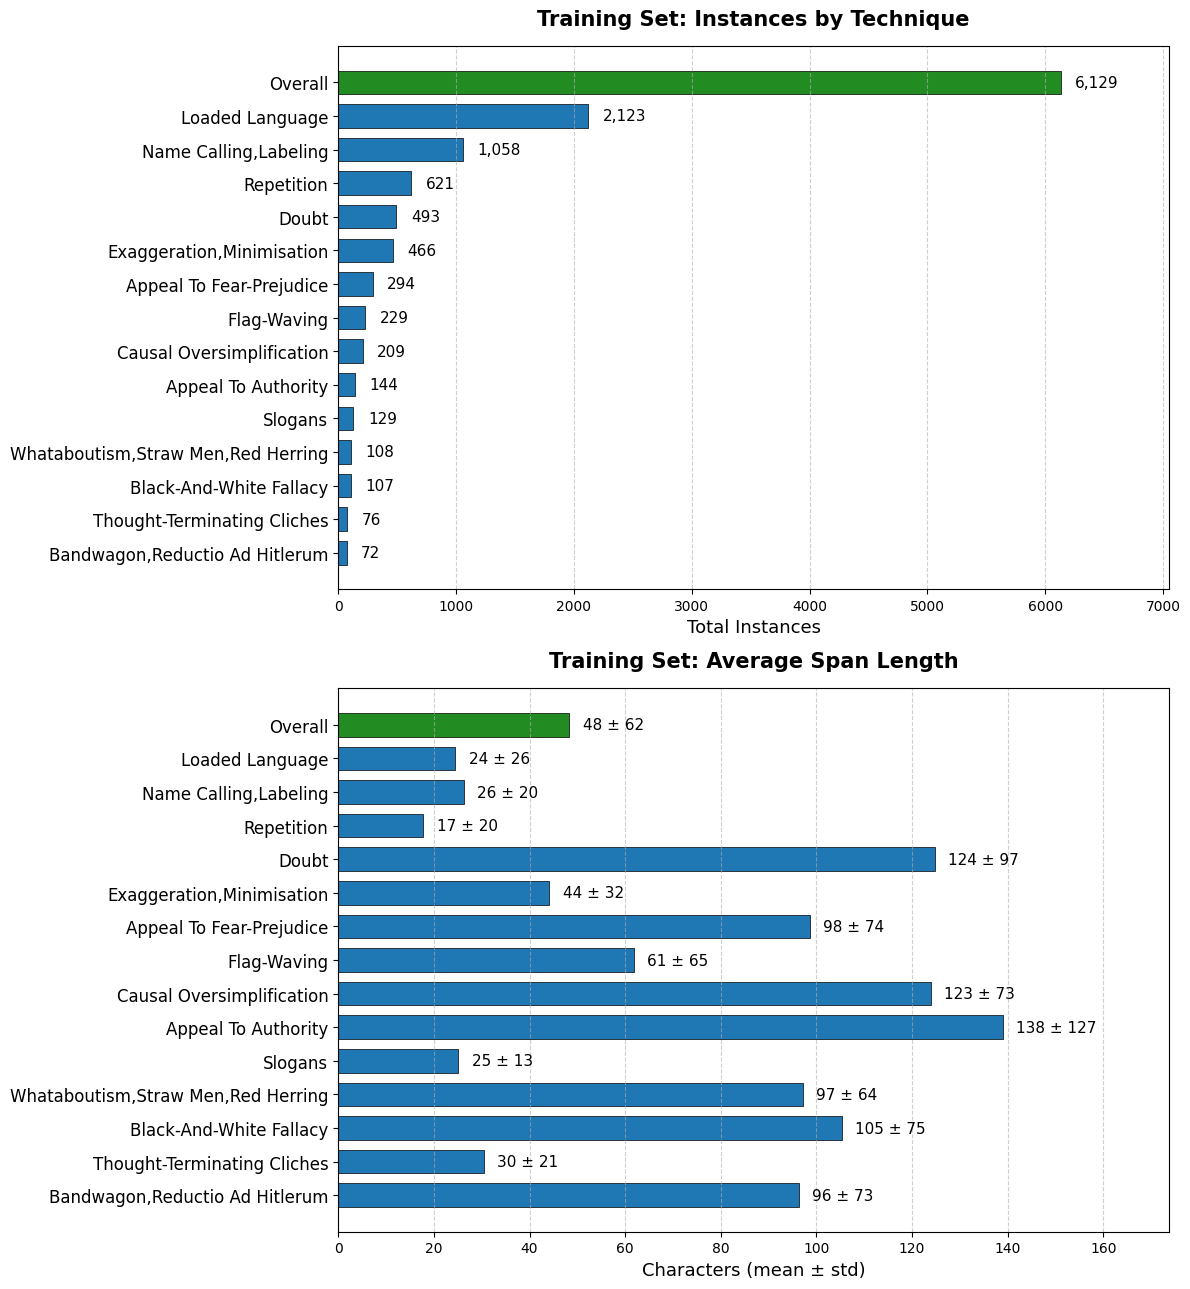

In [ ]:
# 1. Calculate statistics per technique from our DataFrame
stats = df.groupby('technique').agg(
    instances=('article_id', 'count'),
    mean_len=('span_length', 'mean'),
    std_len=('span_length', 'std')
).reset_index()

# Sort by instances descending
stats = stats.sort_values('instances', ascending=False).reset_index(drop=True)

# Calculate 'Overall' metrics
overall_instances = len(df)
overall_mean = df['span_length'].mean()
overall_std = df['span_length'].std()

# 2. Prepare data arrays and clean up label names for display
techniques = ['Overall'] + stats['technique'].tolist()
# Replace underscores with spaces and apply Title Casing for a cleaner look
display_techniques = [t.replace('_', ' ').title() for t in techniques]

instances = [overall_instances] + stats['instances'].tolist()
means = [overall_mean] + stats['mean_len'].tolist()
stds = [overall_std] + stats['std_len'].tolist()

y_positions = np.arange(len(techniques))

# 3. Create the figure (Made wider and taller to fit the text beautifully)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 13), sharex=False)

# --- Top Plot: Instances ---
# Added edgecolor for a crisper visual definition
bars1 = ax1.barh(y_positions, instances, height=0.7, color='#1f77b4', edgecolor='black', linewidth=0.5)
bars1[0].set_color('forestgreen') # Overall bar is green
bars1[0].set_edgecolor('black')

ax1.set_yticks(y_positions)
ax1.set_yticklabels(display_techniques, fontsize=12)
ax1.invert_yaxis()
ax1.set_title("Training Set: Instances by Technique", fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel("Total Instances", fontsize=13)
ax1.grid(axis='x', linestyle='--', alpha=0.6)

# Add text labels (counts) just outside the bars dynamically
for i, v in enumerate(instances):
    ax1.text(v + (max(instances) * 0.02), i, f"{v:,}", va='center', fontsize=11, fontweight='500')
ax1.set_xlim(0, max(instances) * 1.15)

# --- Bottom Plot: Character Means ---
bars2 = ax2.barh(y_positions, means, height=0.7, color='#1f77b4', edgecolor='black', linewidth=0.5)
bars2[0].set_color('forestgreen')
bars2[0].set_edgecolor('black')

ax2.set_yticks(y_positions)
ax2.set_yticklabels(display_techniques, fontsize=12)
ax2.invert_yaxis()
ax2.set_title("Training Set: Average Span Length", fontsize=15, fontweight='bold', pad=15)
ax2.set_xlabel("Characters (mean ± std)", fontsize=13)
ax2.grid(axis='x', linestyle='--', alpha=0.6)

# Add text labels (mean ± std) dynamically
for i, (m, s) in enumerate(zip(means, stds)):
    s = 0 if np.isnan(s) else s
    ax2.text(m + (max(means) * 0.02), i, f"{int(m)} ± {int(s)}", va='center', fontsize=11)

ax2.set_xlim(0, max(means) * 1.25)

# Adjust layout so the long technique names fit perfectly without getting cropped
plt.tight_layout()
plt.show()

The first chart reveals a massive class imbalance across the 6,129 training instances. Over half of the dataset consists of just two techniques (Loaded Language and Name Calling/Labeling), while strategies like Bandwagon are extremely rare.

The second chart highlights a great variance in how long these propaganda snippets actually are. Techniques like Repetition and Loaded Language are typically just single words or short phrases, whereas Appeal to Authority and Doubt stretch into long, highly unpredictable sentence-level spans as shown by their massive standard deviations. This means that sequence labeling model (RoBERTa) cannot rely on length as a clue. It has to learn how to identify propaganda that is 2 words long, while simultaneously learning how to identify propaganda that spans across 5 entire sentences.

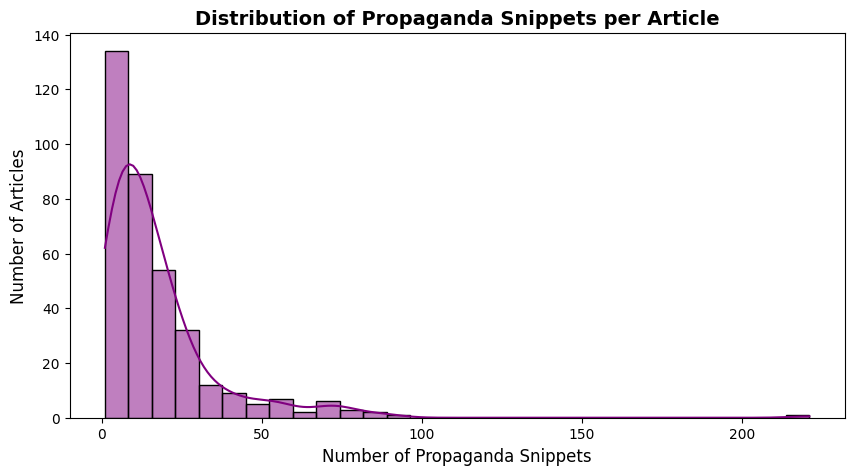

Average snippets per article: 17.2
Maximum snippets in a single article: 221


In [ ]:
# Group by article to see how many propaganda spans are in each text
spans_per_article = df.groupby('article_id').size()

plt.figure(figsize=(10, 5))
sns.histplot(spans_per_article, bins=30, color="purple", kde=True)
plt.title("Distribution of Propaganda Snippets per Article", fontsize=14, fontweight='bold')
plt.xlabel("Number of Propaganda Snippets", fontsize=12)
plt.ylabel("Number of Articles", fontsize=12)
plt.show()

print(f"Average snippets per article: {spans_per_article.mean():.1f}")
print(f"Maximum snippets in a single article: {spans_per_article.max()}")

This histogram reveals a heavily right-skewed distribution, showing that the vast majority of news articles contain a relatively low concentration of propaganda, typically between 0 and 30 snippets. However, the long tail highlights the presence of a few extreme outliers—likely highly partisan or specifically engineered articles—which drag the overall average up to 17.2 and include at least one text saturated with a staggering 221 individual propaganda snippets.


Let's calculate how much of the articles in our training dataset is marked as propaganda and how much is plain text

Total Tokens: 158,077 | 'O': 140,135 | Propaganda: 17,942


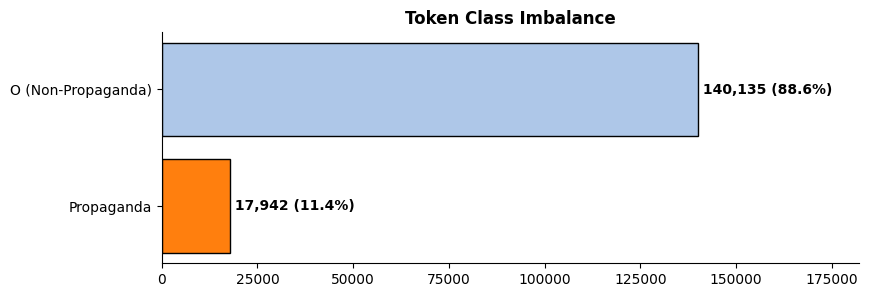

In [ ]:
# 1. Locate and extract dataset (assumes drive is mounted and file exists)
zip_path = glob.glob('/content/drive/MyDrive/Colab Notebooks/Fine_Grained_Propagan*/dataset.zip')[0]
dataset_path = '/content/propaganda_tokenized_dataset'

if not os.path.exists(dataset_path):
    !unzip -q "{zip_path}" -d /content/

# 2. Load and isolate the training split
train_dataset = load_from_disk(dataset_path).train_test_split(test_size=0.1, seed=42)['train']

# 3. Count tokens quickly using a flattened list comprehension
# This extracts all labels, ignores -100 (padding), and puts them in one giant list
all_labels = [
    label for item in train_dataset
    for label in item.get('labels', item.get('ner_tags', []))
    if label != -100
]

total_tokens = len(all_labels)
o_tokens = all_labels.count(0)
propaganda_tokens = total_tokens - o_tokens

print(f"Total Tokens: {total_tokens:,} | 'O': {o_tokens:,} | Propaganda: {propaganda_tokens:,}")

# 4. Visualize with a Horizontal Bar Chart
fig, ax = plt.subplots(figsize=(9, 3))
counts = [propaganda_tokens, o_tokens]
bars = ax.barh(['Propaganda', 'O (Non-Propaganda)'], counts, color=['#ff7f0e', '#aec7e8'], edgecolor='black')

# Add labels (counts and percentages) directly next to bars
for bar, count in zip(bars, counts):
    ax.text(count, bar.get_y() + bar.get_height()/2, f" {count:,} ({(count/total_tokens)*100:.1f}%)",
            va='center', fontweight='bold')

# Clean formatting
plt.title('Token Class Imbalance', fontweight='bold')
plt.xlim(0, max(counts) * 1.3)  # Give room for text labels
ax.spines[['top', 'right']].set_visible(False)
plt.show()

Let's save the dataset we will need for the next notebook.

In [ ]:

search_path = '/content/drive/MyDrive/Colab Notebooks/Fine_Grained_Propagan*'
folder_matches = glob.glob(search_path)

if not folder_matches:
    raise FileNotFoundError(f"Could not find target folder matching: {search_path}")

target_folder = folder_matches[0]

# 2. Construct the full output path
output_csv_path = os.path.join(target_folder, 'propaganda_train_cleaned.csv')

# 3. Save the cleaned dataset directly to Google Drive
df.to_csv(output_csv_path, index=False)

print(f"Dataset successfully saved to: {output_csv_path}")

Dataset successfully saved to: /content/drive/MyDrive/Colab Notebooks/Fine_Grained_Propaganda_Analysis/propaganda_train_cleaned.csv
